# 🔍 Implémentation BioWord2Vec - Modèle Pré-entraîné

Ce notebook implémente notre modèle **BioWord2Vec** (pré-entraîné sur des textes biomédicaux) pour la recherche d'information sur le dataset TREC-COVID.

## Objectifs
- Charger le dataset TREC-COVID
- Charger un modèle Word2Vec pré-entraîné sur des textes biomédicaux
- Utiliser les fonctions généralistes pour la recherche et l'évaluation
- Évaluer les performances avec NDCG@10 et comparer avec TF-IDF et Word2Vec


## 📦 1. Imports et Configuration


In [1]:
# Imports nécessaires
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
from beir.datasets.data_loader import GenericDataLoader

# Télécharger les données NLTK nécessaires
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# Import our general-purpose evaluation functions
from functions import search, top_k_ideal, evaluate_single_query, evaluate_model

print("✓ Imports terminés")


✓ Imports terminés


c:\Users\KEBDI Lounès\Documents\Projets\env_dossierprojets\lib\site-packages\beir\datasets\data_loader.py:8: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## 📂 2. Chargement des Données


In [2]:
# Chemin vers le dataset TREC-COVID
data_path = "data/trec-covid/trec-covid"

# Vérifier que le dataset existe
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset introuvable à {data_path}. Exécutez d'abord download.py")

print(f"Chargement du dataset depuis: {data_path}")


Chargement du dataset depuis: data/trec-covid/trec-covid


In [3]:
# Charger les données avec BEIR
corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")

print(f"✓ Corpus chargé: {len(corpus)} documents")
print(f"✓ Requêtes chargées: {len(queries)} requêtes")
print(f"✓ Qrels chargés: {len(qrels)} jugements de pertinence")


100%|██████████| 171332/171332 [00:01<00:00, 128589.60it/s]


✓ Corpus chargé: 171332 documents
✓ Requêtes chargées: 50 requêtes
✓ Qrels chargés: 50 jugements de pertinence


In [4]:
# Afficher un exemple de document et de requête
print("Exemple de document:")
doc_id = list(corpus.keys())[0]
doc = corpus[doc_id]
print(f"ID: {doc_id}")
print(f"Titre: {doc['title'][:100]}...")
print(f"Texte: {doc['text'][:200]}...")

print("\nExemple de requête:")
query_id = list(queries.keys())[0]
query = queries[query_id]
print(f"ID: {query_id}")
print(f"Texte: {query}")


Exemple de document:
ID: ug7v899j
Titre: Clinical features of culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Ho...
Texte: OBJECTIVE: This retrospective chart review describes the epidemiology and clinical features of 40 patients with culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Hospital, J...

Exemple de requête:
ID: 1
Texte: what is the origin of COVID-19


## 🔧 3. Préparation des Données


### 3.1. Préparation et Tokenisation des Documents


In [5]:
# Préparer les documents pour BioWord2Vec
# On combine titre et texte, puis on tokenise
documents = []
doc_ids = []

# Charger les stop words
stop_words = set(stopwords.words('english'))

print("Tokenisation des documents...")
for doc_id, doc in corpus.items():
    # Combiner titre et texte
    full_text = f"{doc['title']} {doc['text']}"
    
    # Tokeniser et filtrer les stop words
    tokens = word_tokenize(full_text.lower())
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    
    documents.append(tokens)
    doc_ids.append(doc_id)

print(f"✓ {len(documents)} documents préparés et tokenisés")
print(f"✓ Longueur moyenne: {np.mean([len(doc) for doc in documents]):.0f} mots par document")


Tokenisation des documents...
✓ 171332 documents préparés et tokenisés
✓ Longueur moyenne: 94 mots par document


## 🎯 4. Chargement du Modèle BioWord2Vec Pré-entraîné


### 4.1. Téléchargement et Chargement du Modèle

**BioWord2Vec** :
- Modèle Word2Vec pré-entraîné sur des textes biomédicaux (PubMed, PMC)
- Capture les relations sémantiques spécifiques au domaine médical
- Meilleure compréhension du vocabulaire médical que Word2Vec générique
- Pas besoin d'entraînement, on charge directement le modèle pré-entraîné


In [6]:
import os
import urllib.request
from gensim.models import KeyedVectors

# Configuration des chemins
model_dir = "models"
model_name = "BioWordVec_PubMed_MIMICIII_d200_sub1500000.vec.bin" # Le nom du fichier HuggingFace
model_path = os.path.join(model_dir, model_name)
model_url = "https://huggingface.co/ez613/BioWord2Vec_Sub1500000/resolve/main/biowordvec_sub1500000.bin"

os.makedirs(model_dir, exist_ok=True)

# 1. Vérification / Téléchargement
if not os.path.exists(model_path):
    print(f"⚠️ Modèle introuvable dans {model_path}")
    print("Tentative de téléchargement depuis HuggingFace...")
    try:
        # Ajout d'un User-Agent pour éviter d'être rejeté par le serveur
        opener = urllib.request.build_opener()
        opener.addheaders = [('User-agent', 'Mozilla/5.0')]
        urllib.request.install_opener(opener)
        
        urllib.request.urlretrieve(model_url, model_path)
        print("✓ Téléchargement réussi !")
    except Exception as e:
        print(f"❌ Erreur de téléchargement : {e}")
        print("CONSEIL : Télécharge le fichier manuellement et place-le dans le dossier 'models/'.")
else:
    print(f"✅ Modèle trouvé localement : {model_path}")

# 2. Chargement du modèle
print("Chargement du modèle en mémoire... (cela peut prendre 1 minute)")
try:
    # On charge le modèle (binary=True car c'est un .bin)
    model = KeyedVectors.load_word2vec_format(model_path, binary=True)
    
    print("=" * 30)
    print("🚀 BioWord2Vec PRÊT")
    print(f"- Mots en cache : {len(model)}")
    print(f"- Dimensions : {model.vector_size}")
    print("=" * 30)
    
except Exception as e:
    print(f"❌ Erreur lors du chargement du fichier : {e}")
    print("Vérifiez que le fichier n'est pas corrompu (taille attendue ~1.5 Go).")

✅ Modèle trouvé localement : models\BioWordVec_PubMed_MIMICIII_d200_sub1500000.vec.bin
Chargement du modèle en mémoire... (cela peut prendre 1 minute)
🚀 BioWord2Vec PRÊT
- Mots en cache : 1500000
- Dimensions : 200


### 4.2. Création des Vecteurs de Documents


In [7]:
# Fonction pour créer un vecteur de document à partir des vecteurs de mots
def document_to_vector(tokens, model):
    """
    Convertit un document (liste de tokens) en un vecteur unique.
    Utilise la moyenne des vecteurs de mots (moyenne simple).
    """
    word_vectors = []
    for token in tokens:
        if token in model:
            word_vectors.append(model[token])
    
    if len(word_vectors) == 0:
        # Si aucun mot n'est dans le vocabulaire, retourner un vecteur de zéros
        return np.zeros(model.vector_size)
    
    # Retourner la moyenne des vecteurs de mots
    return np.mean(word_vectors, axis=0)

# Créer les vecteurs pour tous les documents
print("Création des vecteurs de documents...")
doc_vectors = []

for i, tokens in enumerate(documents):
    if (i + 1) % 10000 == 0:
        print(f"  Traitement document {i+1}/{len(documents)}...")
    doc_vector = document_to_vector(tokens, model)
    doc_vectors.append(doc_vector)

# Convertir en numpy array
doc_vectors = np.array(doc_vectors)

print(f"\n✓ Vecteurs de documents créés")
print(f"  - Forme de la matrice: {doc_vectors.shape}")
print(f"  - Dimension des vecteurs: {doc_vectors.shape[1]}")


Création des vecteurs de documents...
  Traitement document 10000/171332...
  Traitement document 20000/171332...
  Traitement document 30000/171332...
  Traitement document 40000/171332...
  Traitement document 50000/171332...
  Traitement document 60000/171332...
  Traitement document 70000/171332...
  Traitement document 80000/171332...
  Traitement document 90000/171332...
  Traitement document 100000/171332...
  Traitement document 110000/171332...
  Traitement document 120000/171332...
  Traitement document 130000/171332...
  Traitement document 140000/171332...
  Traitement document 150000/171332...
  Traitement document 160000/171332...
  Traitement document 170000/171332...

✓ Vecteurs de documents créés
  - Forme de la matrice: (171332, 200)
  - Dimension des vecteurs: 200


### 4.3. Création d'un Vectorizer Compatible avec `search()`


In [8]:
# Créer une classe vectorizer pour BioWord2Vec compatible avec la fonction search()
class BioWord2VecVectorizer:
    """
    Vectorizer BioWord2Vec compatible avec la fonction search() de functions.py
    """
    def __init__(self, model):
        self.model = model
        self.stop_words = set(stopwords.words('english'))
    
    def transform(self, texts):
        """
        Transforme une liste de textes en vecteurs.
        Args:
            texts: Liste de chaînes de caractères
        Returns:
            Array numpy de forme (n_texts, vector_size)
        """
        vectors = []
        for text in texts:
            tokens = word_tokenize(text.lower())
            tokens = [token for token in tokens if token.isalpha() and token not in self.stop_words]
            doc_vector = document_to_vector(tokens, self.model)
            vectors.append(doc_vector)
        return np.array(vectors)

# Créer le vectorizer
vectorizer = BioWord2VecVectorizer(model)

print("✓ Vectorizer BioWord2Vec créé")


✓ Vectorizer BioWord2Vec créé


## 🔍 5. Recherche de Documents Pertinents


### 5.1. Test de Recherche sur une Requête

Nous utilisons la fonction généraliste `search()` de `functions.py` qui fonctionne avec n'importe quel vectorizer.


In [9]:
# Tester la fonction search() sur la première requête
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

print(f"Requête test: {test_query_id}")
print(f"Texte: {test_query_text}\n")

# Utiliser la fonction généraliste search()
results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

print("Top 10 documents trouvés:")
for i, (doc_id, score) in enumerate(results, 1):
    doc = corpus[doc_id]
    print(f"{i}. Doc {doc_id} (score: {score:.4f})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()


Requête test: 1
Texte: what is the origin of COVID-19

Top 10 documents trouvés:
1. Doc beguhous (score: 0.8068)
   Titre: The proximal origin of SARS-CoV-2...

2. Doc jkejiuf2 (score: 0.7927)
   Titre: Coronaviruses: origin and evolution...

3. Doc v9f5jck9 (score: 0.7656)
   Titre: Early evolution and the origin of eukaryotes...

4. Doc dv9m19yk (score: 0.7649)
   Titre: [What is the origin of SARS-CoV-2?]...

5. Doc 4ilpph77 (score: 0.7564)
   Titre: Probable Pangolin Origin of SARS-CoV-2 Associated with the COVID-19 Outbreak...

6. Doc ze73ajsk (score: 0.7400)
   Titre: Commentary: Origin and evolution of pathogenic coronaviruses...

7. Doc u7u75sl0 (score: 0.7380)
   Titre: Strategies to trace back the origin of COVID-19...

8. Doc kvb7moqt (score: 0.7355)
   Titre: Ideas and the origin of evidence during the COVID-19 pandemic....

9. Doc 4977dzxz (score: 0.7355)
   Titre: Ideas and the origin of evidence during the COVID-19 pandemic...

10. Doc gyj5213f (score: 0.7272)
   Titre: 

### 5.2. Comparaison avec le Top 10 Idéal

Comparons les résultats du modèle avec le top 10 idéal basé sur les Qrels.


In [10]:
# Comparer les résultats du modèle avec le top 10 idéal
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

# Obtenir les résultats du modèle
model_results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

# Obtenir le top 10 idéal
ideal_results = top_k_ideal(
    query_id=test_query_id,
    qrels=qrels,
    top_k=10
)

print("=" * 80)
print(f"COMPARAISON POUR LA REQUÊTE {test_query_id}")
print(f"Texte: {test_query_text}")
print("=" * 80)

print("\n📊 TOP 10 RETOURNÉ PAR LE MODÈLE BioWord2Vec:")
print("-" * 80)
for i, (doc_id, biow2v_score) in enumerate(model_results, 1):
    relevance = qrels.get(test_query_id, {}).get(doc_id, 0)
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score BioWord2Vec: {biow2v_score:.4f} | Pertinence réelle: {relevance}")
    print(f"    Titre: {doc['title'][:70]}...")

print("\n✅ TOP 10 IDÉAL (selon les Qrels):")
print("-" * 80)
for i, (doc_id, relevance_score) in enumerate(ideal_results, 1):
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score de pertinence: {relevance_score}")
    print(f"    Titre: {doc['title'][:70]}...")

# Calculer le score NDCG@10 pour cette requête avec evaluate_single_query
ndcg_score = evaluate_single_query(
    query_id=test_query_id,
    model_results=model_results,
    qrels=qrels,
    k=10
)
print(f"\n📈 Score NDCG@10 pour cette requête: {ndcg_score:.4f}")


COMPARAISON POUR LA REQUÊTE 1
Texte: what is the origin of COVID-19

📊 TOP 10 RETOURNÉ PAR LE MODÈLE BioWord2Vec:
--------------------------------------------------------------------------------
 1. Doc beguhous | Score BioWord2Vec: 0.8068 | Pertinence réelle: 2
    Titre: The proximal origin of SARS-CoV-2...
 2. Doc jkejiuf2 | Score BioWord2Vec: 0.7927 | Pertinence réelle: 2
    Titre: Coronaviruses: origin and evolution...
 3. Doc v9f5jck9 | Score BioWord2Vec: 0.7656 | Pertinence réelle: 0
    Titre: Early evolution and the origin of eukaryotes...
 4. Doc dv9m19yk | Score BioWord2Vec: 0.7649 | Pertinence réelle: 1
    Titre: [What is the origin of SARS-CoV-2?]...
 5. Doc 4ilpph77 | Score BioWord2Vec: 0.7564 | Pertinence réelle: 0
    Titre: Probable Pangolin Origin of SARS-CoV-2 Associated with the COVID-19 Ou...
 6. Doc ze73ajsk | Score BioWord2Vec: 0.7400 | Pertinence réelle: 1
    Titre: Commentary: Origin and evolution of pathogenic coronaviruses...
 7. Doc u7u75sl0 | Score BioWo

### 5.3. Recherche sur Toutes les Requêtes


In [11]:
# Rechercher les documents pertinents pour toutes les requêtes
print("Recherche sur toutes les requêtes...")
print(f"(Traitement de {len(queries)} requêtes)\n")

# Dictionnaire pour stocker tous les résultats : {query_id: [(doc_id, score), ...]}
all_model_results = {}

for i, (query_id, query_text) in enumerate(queries.items(), 1):
    if i % 10 == 0:
        print(f"  Traitement requête {i}/{len(queries)}...")
    
    # Rechercher les top 10 documents avec la fonction généraliste
    results = search(
        query_text=query_text,
        doc_vectors=doc_vectors,
        doc_ids=doc_ids,
        vectorizer=vectorizer,
        top_k=10
    )
    
    all_model_results[query_id] = results

print(f"\n✓ Recherche terminée pour toutes les requêtes")


Recherche sur toutes les requêtes...
(Traitement de 50 requêtes)

  Traitement requête 10/50...
  Traitement requête 20/50...
  Traitement requête 30/50...
  Traitement requête 40/50...
  Traitement requête 50/50...

✓ Recherche terminée pour toutes les requêtes


## 📊 6. Évaluation avec NDCG@10


In [12]:
# Évaluer le modèle sur toutes les requêtes avec evaluate_model
evaluation_results = evaluate_model(
    queries=queries,
    all_model_results=all_model_results,
    qrels=qrels,
    k=10
)


EVALUATION SUMMARY
Mean NDCG@10: 0.7366
Min NDCG@10: 0.0000
Max NDCG@10: 1.0000
Std NDCG@10: 0.3029
Number of queries: 50


### 6.1. Distribution des Scores


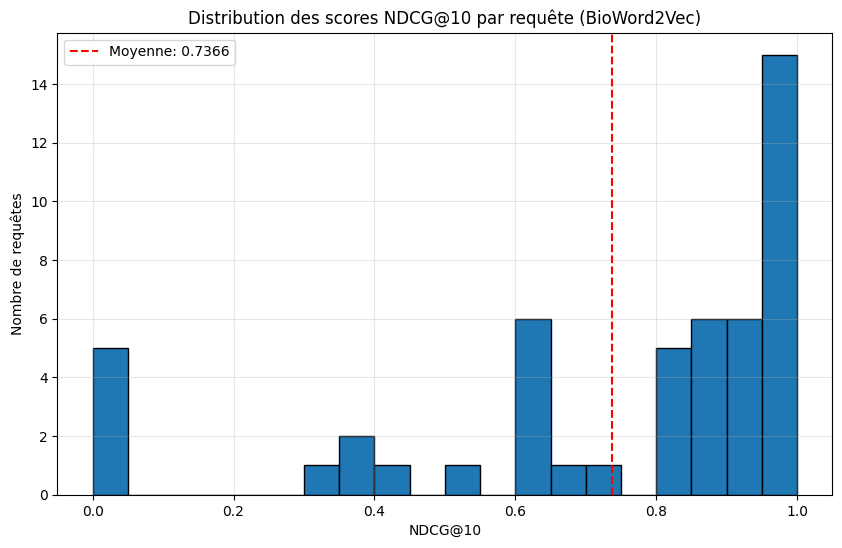

In [13]:
# Afficher la distribution des scores NDCG@10
ndcg_scores = evaluation_results['scores']

plt.figure(figsize=(10, 6))
plt.hist(list(ndcg_scores.values()), bins=20, edgecolor='black')
plt.xlabel('NDCG@10')
plt.ylabel('Nombre de requêtes')
plt.title('Distribution des scores NDCG@10 par requête (BioWord2Vec)')
plt.axvline(evaluation_results['mean_score'], color='r', linestyle='--', 
            label=f'Moyenne: {evaluation_results["mean_score"]:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 📈 7. Analyse des Résultats


In [14]:
# Afficher les meilleures et pires requêtes
ndcg_df = pd.DataFrame([
    {'query_id': qid, 'ndcg@10': score} 
    for qid, score in ndcg_scores.items()
]).sort_values('ndcg@10', ascending=False)

print("Top 5 meilleures requêtes:")
print(ndcg_df.head())
print("\nTop 5 pires requêtes:")
print(ndcg_df.tail())


Top 5 meilleures requêtes:
   query_id   ndcg@10
11       12  1.000000
14       15  1.000000
42       43  1.000000
38       39  0.992382
45       46  0.992366

Top 5 pires requêtes:
   query_id  ndcg@10
10       11      0.0
33       34      0.0
29       30      0.0
36       37      0.0
49       50      0.0


In [15]:
# Analyser une requête avec un bon score
best_query_id = ndcg_df.iloc[0]['query_id']
best_query_text = queries[best_query_id]
best_ndcg = ndcg_df.iloc[0]['ndcg@10']

print(f"\nRequête avec le meilleur NDCG@10 ({best_ndcg:.4f}):")
print(f"ID: {best_query_id}")
print(f"Texte: {best_query_text}\n")

# Obtenir les résultats du modèle pour cette requête depuis all_model_results
model_results = all_model_results[best_query_id]

print("Top 5 documents retournés:")
for i, (doc_id, score) in enumerate(model_results[:5], 1):
    doc = corpus[doc_id]
    relevance = qrels.get(best_query_id, {}).get(doc_id, 0)
    print(f"{i}. Doc {doc_id} (score BioWord2Vec: {score:.4f}, pertinence réelle: {relevance})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()



Requête avec le meilleur NDCG@10 (1.0000):
ID: 12
Texte: what are best practices in hospitals and at home in maintaining quarantine?

Top 5 documents retournés:
1. Doc ok4j5y5k (score BioWord2Vec: 0.9206, pertinence réelle: 2)
   Titre: Respiratory protection policies and practices among the health care workforce ex...

2. Doc 93whg9zx (score BioWord2Vec: 0.9184, pertinence réelle: 0)
   Titre: Survey of acute hospital infection control resources and services in the Republi...

3. Doc z219kkuq (score BioWord2Vec: 0.9168, pertinence réelle: 0)
   Titre: Guidelines for Frontline Health Care Staff Safety for COVID-19....

4. Doc d2f7kfmv (score BioWord2Vec: 0.9159, pertinence réelle: 0)
   Titre: Commentary: COVID in Care Homes—Challenges and Dilemmas in Healthcare Delivery...

5. Doc 1ub7mcvx (score BioWord2Vec: 0.9159, pertinence réelle: 0)
   Titre: Commentary: COVID in Care Homes-Challenges and Dilemmas in Healthcare Delivery...



## 💾 8. Sauvegarde des Résultats


In [16]:
# Sauvegarder les résultats pour comparaison avec TF-IDF et Word2Vec
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Sauvegarder les scores NDCG
ndcg_scores = evaluation_results['scores']
with open(f"{results_dir}/bioword2vec_ndcg_scores.json", "w", encoding="utf-8") as f:
    json.dump(ndcg_scores, f, indent=2)

# Sauvegarder le résumé
summary = {
    "model": "BioWord2Vec",
    "mean_ndcg@10": evaluation_results['mean_score'],
    "min_ndcg@10": evaluation_results['min_score'],
    "max_ndcg@10": evaluation_results['max_score'],
    "std_ndcg@10": evaluation_results['std_score'],
    "num_queries": evaluation_results['num_queries'],
    "num_documents": len(doc_ids)
}

with open(f"{results_dir}/bioword2vec_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"✓ Résultats sauvegardés dans {results_dir}/")
print(f"  - bioword2vec_ndcg_scores.json")
print(f"  - bioword2vec_summary.json")


✓ Résultats sauvegardés dans results/
  - bioword2vec_ndcg_scores.json
  - bioword2vec_summary.json


## 🔬 9. Expérimentation : Recherche Uniquement sur les Titres

Dans cette section, nous testons une approche simplifiée en utilisant **uniquement les titres** des documents au lieu de combiner titre + texte. Cela permet de voir si les titres seuls contiennent suffisamment d'information pour une recherche efficace.


### 9.1. Préparation des Documents (Titres Uniquement)


In [17]:
# Préparer les documents en utilisant UNIQUEMENT les titres
documents_title_only = []
doc_ids_title_only = []

print("Tokenisation des titres uniquement...")
for doc_id, doc in corpus.items():
    # Utiliser uniquement le titre
    title_text = doc['title']
    
    # Tokeniser et filtrer les stop words
    tokens = word_tokenize(title_text.lower())
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    
    documents_title_only.append(tokens)
    doc_ids_title_only.append(doc_id)

print(f"✓ {len(documents_title_only)} documents préparés (titres uniquement)")
print(f"✓ Longueur moyenne: {np.mean([len(doc) for doc in documents_title_only]):.0f} mots par titre")


Tokenisation des titres uniquement...
✓ 171332 documents préparés (titres uniquement)
✓ Longueur moyenne: 8 mots par titre


### 9.2. Création des Vecteurs de Documents (Titres)


In [18]:
# Créer les vecteurs pour tous les documents (titres uniquement)
print("Création des vecteurs de documents (titres uniquement)...")
doc_vectors_title_only = []

for i, tokens in enumerate(documents_title_only):
    if (i + 1) % 10000 == 0:
        print(f"  Traitement document {i+1}/{len(documents_title_only)}...")
    doc_vector = document_to_vector(tokens, model)
    doc_vectors_title_only.append(doc_vector)

# Convertir en numpy array
doc_vectors_title_only = np.array(doc_vectors_title_only)

print(f"\n✓ Vecteurs de documents créés (titres uniquement)")
print(f"  - Forme de la matrice: {doc_vectors_title_only.shape}")
print(f"  - Dimension des vecteurs: {doc_vectors_title_only.shape[1]}")


Création des vecteurs de documents (titres uniquement)...
  Traitement document 10000/171332...
  Traitement document 20000/171332...
  Traitement document 30000/171332...
  Traitement document 40000/171332...
  Traitement document 50000/171332...
  Traitement document 60000/171332...
  Traitement document 70000/171332...
  Traitement document 80000/171332...
  Traitement document 90000/171332...
  Traitement document 100000/171332...
  Traitement document 110000/171332...
  Traitement document 120000/171332...
  Traitement document 130000/171332...
  Traitement document 140000/171332...
  Traitement document 150000/171332...
  Traitement document 160000/171332...
  Traitement document 170000/171332...

✓ Vecteurs de documents créés (titres uniquement)
  - Forme de la matrice: (171332, 200)
  - Dimension des vecteurs: 200


### 9.3. Recherche sur Toutes les Requêtes (Titres Uniquement)


In [19]:
# Rechercher les documents pertinents pour toutes les requêtes (titres uniquement)
print("Recherche sur toutes les requêtes (titres uniquement)...")
print(f"(Traitement de {len(queries)} requêtes)\n")

# Dictionnaire pour stocker tous les résultats : {query_id: [(doc_id, score), ...]}
all_model_results_title_only = {}

for i, (query_id, query_text) in enumerate(queries.items(), 1):
    if i % 10 == 0:
        print(f"  Traitement requête {i}/{len(queries)}...")
    
    # Rechercher les top 10 documents avec la fonction généraliste
    results = search(
        query_text=query_text,
        doc_vectors=doc_vectors_title_only,
        doc_ids=doc_ids_title_only,
        vectorizer=vectorizer,
        top_k=10
    )
    
    all_model_results_title_only[query_id] = results

print(f"\n✓ Recherche terminée pour toutes les requêtes (titres uniquement)")


Recherche sur toutes les requêtes (titres uniquement)...
(Traitement de 50 requêtes)

  Traitement requête 10/50...
  Traitement requête 20/50...
  Traitement requête 30/50...
  Traitement requête 40/50...
  Traitement requête 50/50...

✓ Recherche terminée pour toutes les requêtes (titres uniquement)


### 9.4. Évaluation avec NDCG@10 (Titres Uniquement)


In [20]:
# Évaluer le modèle sur toutes les requêtes avec evaluate_model (titres uniquement)
evaluation_results_title_only = evaluate_model(
    queries=queries,
    all_model_results=all_model_results_title_only,
    qrels=qrels,
    k=10
)


EVALUATION SUMMARY
Mean NDCG@10: 0.7081
Min NDCG@10: 0.0000
Max NDCG@10: 1.0000
Std NDCG@10: 0.2789
Number of queries: 50


### 9.5. Sauvegarde des Résultats (Titres Uniquement)


In [21]:
# Sauvegarder les résultats pour comparaison (titres uniquement)
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Sauvegarder les scores NDCG
ndcg_scores_title_only = evaluation_results_title_only['scores']
with open(f"{results_dir}/bioword2vec_title_ndcg_scores.json", "w", encoding="utf-8") as f:
    json.dump(ndcg_scores_title_only, f, indent=2)

# Sauvegarder le résumé
summary_title_only = {
    "model": "BioWord2Vec",
    "input_type": "title_only",
    "mean_ndcg@10": evaluation_results_title_only['mean_score'],
    "min_ndcg@10": evaluation_results_title_only['min_score'],
    "max_ndcg@10": evaluation_results_title_only['max_score'],
    "std_ndcg@10": evaluation_results_title_only['std_score'],
    "num_queries": evaluation_results_title_only['num_queries'],
    "num_documents": len(doc_ids_title_only)
}

with open(f"{results_dir}/bioword2vec_title_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_title_only, f, indent=2)

print(f"✓ Résultats sauvegardés dans {results_dir}/")
print(f"  - bioword2vec_title_ndcg_scores.json")
print(f"  - bioword2vec_title_summary.json")
print(f"\n📊 Comparaison rapide:")
print(f"  - Avec titre + texte: NDCG@10 = {evaluation_results['mean_score']:.4f}")
print(f"  - Avec titres uniquement: NDCG@10 = {evaluation_results_title_only['mean_score']:.4f}")


✓ Résultats sauvegardés dans results/
  - bioword2vec_title_ndcg_scores.json
  - bioword2vec_title_summary.json

📊 Comparaison rapide:
  - Avec titre + texte: NDCG@10 = 0.7366
  - Avec titres uniquement: NDCG@10 = 0.7081


## ✅ Conclusion

Nous avons implémenté avec succès notre modèle **BioWord2Vec** en utilisant les fonctions généralistes :

- ✅ Corpus tokenisé et préparé pour BioWord2Vec
- ✅ Modèle BioWord2Vec pré-entraîné chargé
- ✅ Vecteurs de documents créés
- ✅ Recherche effectuée avec la fonction généraliste `search()`
- ✅ Évaluation avec NDCG@10 utilisant `evaluate_model()` et `evaluate_single_query()`
- ✅ Score obtenu et sauvegardé

**Avantages de l'approche généraliste :**
- Code réutilisable avec TF-IDF, Word2Vec ou autres modèles
- Fonctions testées et maintenables
- Facile à comparer différents modèles

**Avantages de BioWord2Vec :**
- Pré-entraîné sur des textes biomédicaux (PubMed, PMC)
- Meilleure compréhension du vocabulaire médical
- Pas besoin d'entraînement, chargement direct

**Prochaines étapes :**
- Comparer les performances BioWord2Vec vs TF-IDF vs Word2Vec
- Analyser les différences de performance selon le domaine médical
- Expérimenter avec d'autres méthodes d'agrégation (moyenne pondérée, etc.)
